In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor

In [82]:
data = pd.read_csv("Offshore_official_data_incl_prices.csv")


In [83]:
len(data)

70128

In [84]:
# Creating lag features for time-series data

def create_lag_features(data, lag_steps=1):
    for i in range(1, lag_steps + 1):
        data[f'lag_{i}'] = data['volume'].shift(i)

    return data

# Applying lag feature creation to the dataset

lagged_data = create_lag_features(data, lag_steps=1)

In [88]:
# Differencing technique for handling non-stationary data
data['rolling_mean_3'] = data['volume'].rolling(window=3).mean()
data = data.dropna()

In [90]:
data.head()

,Unnamed: 0,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,...,correct_days,date,month,week_number,max_capacity,log_volume,ratio_VC,prijs_excl_belastingen,lag_1,rolling_mean_3
2,2017-01-01 02:00:00,20170101,2,208.585001,89.285714,87.857143,10191.50,96.000000,2017-01-01-03,872500,...,2017-01-01-03,2017-01-01,2017-01,1,861299.705697,13.679119,1.013004,0.0520,883749.0,876583.333333
3,2017-01-01 03:00:00,20170101,3,209.977979,90.000000,90.000000,10182.25,96.142857,2017-01-01-04,889750,...,2017-01-01-04,2017-01-01,2017-01,1,861300.397937,13.698697,1.033031,0.0410,872500.0,881999.666667
4,2017-01-01 04:00:00,20170101,4,208.541568,89.285714,87.142857,10176.25,95.571429,2017-01-01-05,893251,...,2017-01-01-05,2017-01-01,2017-01,1,861301.078959,13.702624,1.037095,0.0390,889750.0,885167.000000
5,2017-01-01 05:00:00,20170101,5,210.719165,92.142857,93.571429,10169.50,95.285714,2017-01-01-06,896751,...,2017-01-01-06,2017-01-01,2017-01,1,861300.695580,13.706535,1.041159,0.0359,893251.0,893250.666667
6,2017-01-01 06:00:00,20170101,6,212.130163,94.285714,94.285714,10165.50,95.428571,2017-01-01-07,895250,...,2017-01-01-07,2017-01-01,2017-01,1,861300.109115,13.704859,1.039417,0.0350,896751.0,895084.000000


In [92]:
X = data.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)

# our target variable
y = data["volume"]
y_log = data["log_volume"]
X_train = X[X["date"] < "2024-12-25"]
X_test = X[X["date"] >= "2024-12-25"]

# Label
y_train = y[:X_train.shape[0]] #list slice: from beginning to end of X-train
y_test = y[X_train.shape[0]:] #list slice: from end of X-train to the end of the data
y_train_log = y_log[:X_train.shape[0]]
y_test_log = y_log[X_train.shape[0]:]

In [94]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(69498, 18)
(69498,)
(165,)
(165, 18)
(69498,)
(165,)


In [96]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage",  
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]
X_train_p = X_train.loc[:, numeric_features]
X_test_p = X_test.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_p = preprocessor.fit_transform(X_train_p)
X_test_norm_p = preprocessor.fit_transform(X_test_p)
X_train_p = pd.DataFrame(X_train_norm_p, columns=X_train_p.columns.values, index=X_train_p.index.values)
X_test_p = pd.DataFrame(X_test_norm_p, columns = X_test_p.columns.values, index=X_test_p.index.values)


In [98]:
print(X_train_p.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test_p.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(69498, 9)
(69498,)
(165,)
(165, 9)
(69498,)
(165,)


In [100]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_p.fit(X_train_p, y_train) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_p = cv_XGB_p.best_estimator_
XGB_pred_p = XGB_model_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test, XGB_pred_p))


Mean cross-validated score of the best_estimator: 0.9360712766647339
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  694555669535.512


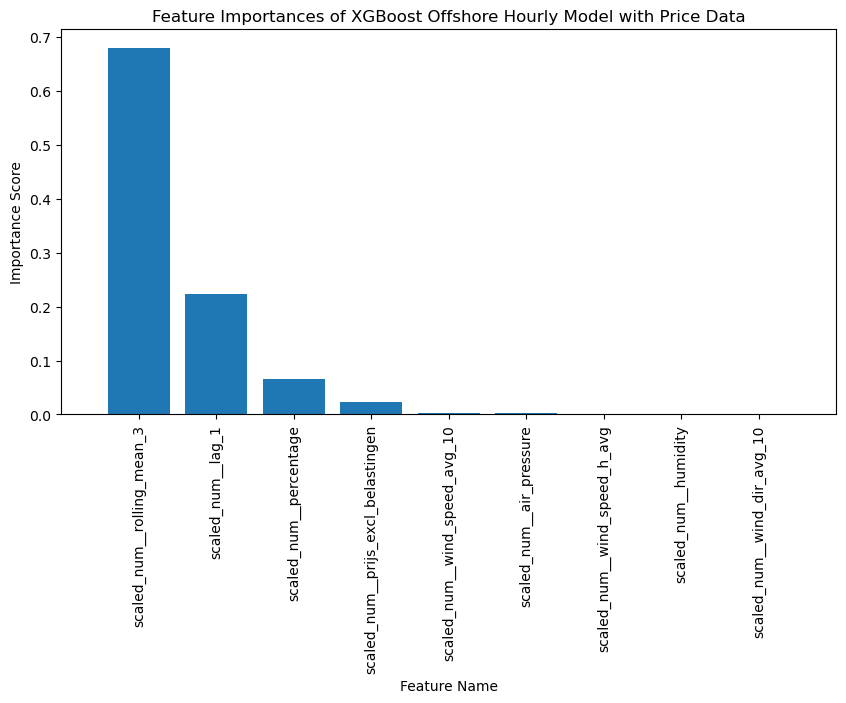

In [129]:
importances = XGB_model_p.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances of XGBoost Offshore Hourly Model with Price Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

# Logged version

In [21]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_log_p.fit(X_train_p, y_train_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_log_p = cv_XGB_log_p.best_estimator_
XGB_pred_log_p = XGB_model_log_p.predict(X_test_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_log, XGB_pred_log_p))


Mean cross-validated score of the best_estimator: 0.5816259516947639
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  5.80708866299599


In [22]:
x_axis_train = data["date"][:len(y_train_log)]
x_axis_test = data["date"][len(y_train_log):]
x_axis_train[0:5]
print(len(x_axis_train))
print(len(x_axis_test))

69960
168


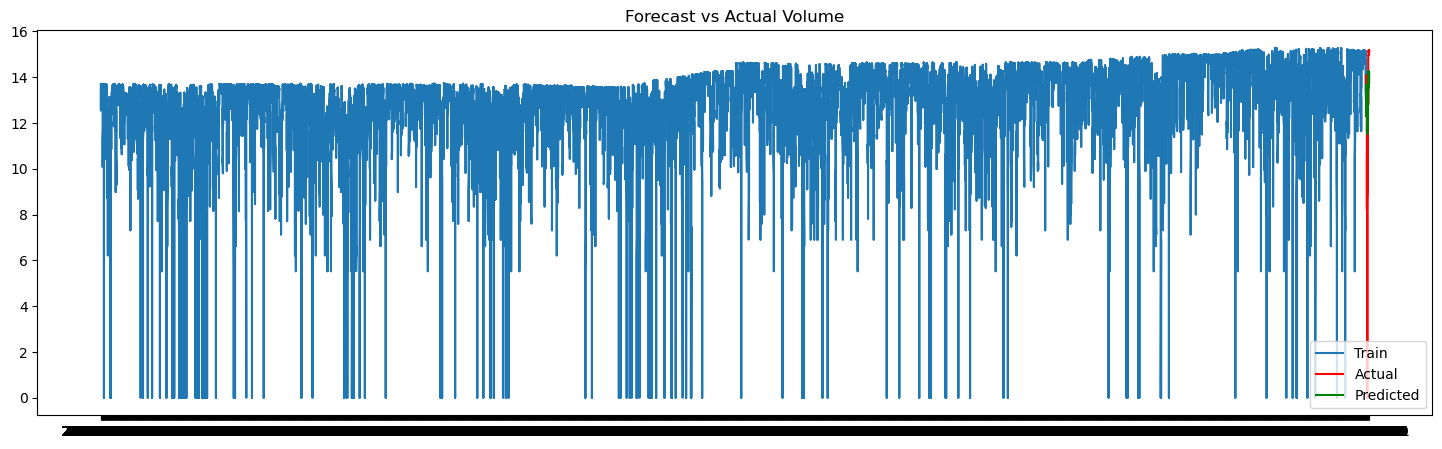

In [23]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_train, y_train_log, label="Train")
plt.plot(x_axis_test, y_test_log, label="Actual", color='red')
plt.plot(x_axis_test, XGB_pred_log_p, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Monthly

In [40]:
# Convert hourly data to monthly data
db_monthly = data.groupby('month').mean(numeric_only=True)
# Split into train and test set
train_db = db_monthly[db_monthly.index <= '2024-06']
test_db = db_monthly[db_monthly.index > '2024-06']

X_month = db_monthly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_month_log = db_monthly["log_volume"]
y_month = db_monthly["volume"]

# Features
X_train_month = X_month[X_month.index <= '2024-06']
X_test_month = X_month[(X_month.index > '2024-06')]


# Label log
y_train_month_log = y_month_log[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month_log = y_month_log[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data

# Label
y_train_month = y_month[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month = y_month[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data



In [43]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 12)
(6, 12)
(90,)
(6,)
(90,)
(6,)


In [45]:
print(X_train_month["prijs_excl_belastingen"].dtype)

float64


In [47]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]
X_train_month_p = X_train_month.loc[:, numeric_features]
X_test_month_p = X_test_month.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_month_p = preprocessor.fit_transform(X_train_month_p)
X_test_norm_month_p = preprocessor.fit_transform(X_test_month_p)


In [49]:
#add feature names back 
X_train_month = pd.DataFrame(X_train_norm_month_p, columns=X_train_month_p.columns.values, index=X_train_month_p.index.values)

X_test_month = pd.DataFrame(X_test_norm_month_p, columns = X_test_month_p.columns.values, index=X_test_month_p.index.values)

X_train_month_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,prijs_excl_belastingen,lag_1,rolling_mean_3
month,,,,,,,,,
2017-01,196.177050,61.469780,61.575026,10219.833906,85.249117,0.500606,0.049015,431761.013736,431746.592033
2017-02,165.060252,75.307011,75.433870,10144.316964,87.309524,0.643716,0.037910,554483.919643,554446.593750
2017-03,192.136378,64.632882,64.570503,10148.379704,82.628616,0.468991,0.035396,403882.701613,403841.594086
2017-04,252.841156,61.532583,61.610505,10203.872801,76.233103,0.448579,0.036291,385668.601173,385707.583578
2017-05,168.058414,56.660532,56.690538,10171.883378,77.414530,0.358247,0.035650,309723.987854,309717.802519


In [51]:
print(X_train_month_p.shape)
print(X_test_month_p.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 9)
(6, 9)
(90,)
(6,)
(90,)
(6,)


In [64]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_log_p.fit(X_train_month_p, y_train_month_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_log_p = cv_XGB_month_log_p.best_estimator_
XGB_pred_month_log_p = XGB_model_month_log_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month_log, XGB_pred_month_log_p))

Mean cross-validated score of the best_estimator: 0.6431481835570214
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  0.49420418392495685


In [53]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_p.fit(X_train_month_p, y_train_month) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_p = cv_XGB_month_p.best_estimator_
XGB_pred_month_p = XGB_model_month_p.predict(X_test_month_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month, XGB_pred_month_p))


Mean cross-validated score of the best_estimator: 0.8666329893263974
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  222563653842.85522


/Users/fmtetteroo/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


# Weekly

In [55]:
# Convert hourly data to weekly data
db_weekly = data.groupby('week_number').mean(numeric_only=True)

X_week = db_weekly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)


# our target variable
y_week = db_weekly["volume"]
y_week_log = db_weekly["log_volume"]

# Features
X_train_week = X_week[X_week.index <= 406]
X_test_week = X_week[(X_week.index > 406)]

# Label
y_train_week = y_week[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week = y_week[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

# Label Log
y_train_week_log = y_week_log[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week_log = y_week_log[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

In [57]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 11)
(12, 11)
(406,)
(12,)
(406,)
(12,)


In [59]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]
X_train_week_p = X_train_week.loc[:, numeric_features]
X_test_week_p = X_test_week.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_week_p = preprocessor.fit_transform(X_train_week_p)
X_test_norm_week_p = preprocessor.fit_transform(X_test_week_p)

In [61]:
#add feature names back 
X_train_week_p = pd.DataFrame(X_train_norm_week_p, columns=X_train_week_p.columns.values, index=X_train_week_p.index.values)

X_test_week_p = pd.DataFrame(X_test_norm_week_p, columns = X_test_week_p.columns.values, index=X_test_week_p.index.values)

X_train_week_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,prijs_excl_belastingen,lag_1,rolling_mean_3
1,0.959893,0.780474,0.781010,1.326430,-0.026382,1.168905,-0.610973,-0.245448,-0.245478
2,1.287998,1.270758,1.272789,-0.661653,0.516703,1.007488,-0.585829,-0.313406,-0.313187
3,-1.001552,-1.976019,-1.977914,2.289382,0.995128,-1.449021,-0.365006,-1.173389,-1.174151
4,-0.369357,-1.243582,-1.238203,1.116265,0.904156,-0.599141,-0.380661,-0.882335,-0.882050
5,-0.969311,-0.351467,-0.363225,-0.763257,1.450244,0.525847,-0.525758,-0.471991,-0.471738


In [63]:
print(X_train_week_p.shape)
print(X_test_week_p.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 9)
(12, 9)
(406,)
(12,)
(406,)
(12,)


In [65]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_p.fit(X_train_week_p, y_train_week) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_p = cv_XGB_week_p.best_estimator_
XGB_pred_week_p = XGB_model_week_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week, XGB_pred_week_p))


Mean cross-validated score of the best_estimator: 0.9692020713668669
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1451700834275.6448


In [72]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_log_p.fit(X_train_week_p, y_train_week_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_log_p = cv_XGB_week_log_p.best_estimator_
XGB_pred_week_log_p = XGB_model_week_log_p.predict(X_test_week_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week_log, XGB_pred_week_log_p))

Mean cross-validated score of the best_estimator: 0.825978974846695
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.4293384079192555


# Daily

In [67]:
data['date2'] = pd.to_datetime(data['date'], format='ISO8601')
db_daily = data.groupby('date2').mean(numeric_only=True)
# Split into train and test set
db_daily.index = pd.to_datetime(db_daily.index)

X_day = db_daily.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", 'max_capacity'], #are always 0 and can be ignored
                      axis=1)

#our targer variable
y_day = db_daily["volume"]
y_day_log = db_daily["log_volume"]

# Features
X_train_day = X_day[X_day.index <= '2024-11-01']
X_test_day = X_day[X_day.index > '2024-11-01']

# Label
y_train_day = y_day[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day = y_day[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

# Label log
y_train_day_log = y_day_log[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day_log = y_day_log[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_97450/4229511020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date2'] = pd.to_datetime(data['date'], format='ISO8601')


In [69]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 12)
(60, 12)
(2862,)
(60,)
(2862,)
(60,)


In [71]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", 
                    "prijs_excl_belastingen", "lag_1", "rolling_mean_3"]
X_train_day_p = X_train_day.loc[:, numeric_features]
X_test_day_p = X_test_day.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_day_p = preprocessor.fit_transform(X_train_day_p)
X_test_norm_day_p = preprocessor.fit_transform(X_test_day_p)

In [73]:
#add feature names back 
X_train_day_p = pd.DataFrame(X_train_norm_day_p, columns=X_train_day_p.columns.values, index=X_train_day_p.index.values)
X_test_day_p = pd.DataFrame(X_test_norm_day_p, columns = X_test_day_p.columns.values, index=X_test_day_p.index.values)
X_train_day_p.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,prijs_excl_belastingen,lag_1,rolling_mean_3
2017-01-01,0.504635,0.531850,0.487005,0.186949,1.475317,0.928814,-0.501652,-0.156665,-0.155400
2017-01-02,1.793325,0.238455,0.261307,0.785036,-0.779581,1.204230,-0.429538,-0.054581,-0.056539
2017-01-03,1.065553,1.145252,1.178920,0.489870,0.370594,1.537071,-0.581624,0.058903,0.059426
2017-01-04,1.787011,1.980410,1.969344,0.196092,-1.046410,1.625917,-0.619468,0.113025,0.111564
2017-01-05,-1.235747,-0.353700,-0.372650,1.769222,-0.969872,-0.252036,-0.586095,-0.588390,-0.586883


In [75]:
print(X_train_day_p.shape)
print(X_test_day_p.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 9)
(60, 9)
(2862,)
(60,)
(2862,)
(60,)


In [77]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_p.fit(X_train_day_p, y_train_day) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_p = cv_XGB_day_p.best_estimator_
XGB_pred_day_p = XGB_model_day_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day, XGB_pred_day_p))

Mean cross-validated score of the best_estimator: 0.9690328028203122
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1863103841944.4336


In [80]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_log_p = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_log_p.fit(X_train_day_p, y_train_day_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_log_p.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_log_p.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_log_p = cv_XGB_day_log_p.best_estimator_
XGB_pred_day_log_p = XGB_model_day_log_p.predict(X_test_day_p)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day_log, XGB_pred_day_log_p))

Mean cross-validated score of the best_estimator: 0.8850623528735724
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  2.6598787941753077


# Pretty graphs official styling

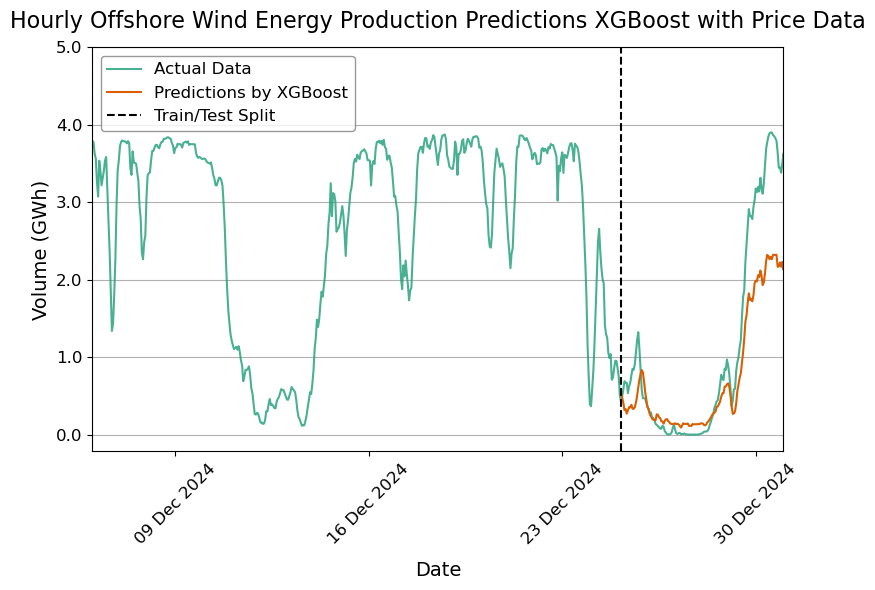

In [131]:
from sktime.forecasting.model_selection import temporal_train_test_split
off_df = pd.read_csv("final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
off_df = off_df[off_df['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
off_df[['date', 'hour']] = off_df['correct_days'].str.rsplit('-', n=1, expand=True)
off_df['hour'] = off_df['hour'].astype(int) - 1
off_df['datetime'] = pd.to_datetime(off_df['date']) + pd.to_timedelta(off_df['hour'], unit='h')
off_df = off_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
off_df = off_df.set_index('datetime')

# Split data into target and exogenous variables
y_h = off_df['volume']
X_h = off_df.drop('volume', axis=1)  # All exogenous variables

# Create train/test split
y_train_off_h, y_test_off_h, X_train_off_h, X_test_off_h = temporal_train_test_split(y_h, X_h, test_size=0.00239)

y_test_off_h = y_test_off_h.iloc[3:]

import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Function to convert to millions
def millions(x, pos):
    return f'{x * 1e-6:.1f}'


# ===== Hourly - Offshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(off_df.index), off_df['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_off_h.index), XGB_pred_p, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_off_h.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Hourly Offshore Wind Energy Production Predictions XGBoost with Price Data', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'y')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xlim(pd.to_datetime('2024-12-06'), pd.to_datetime('2024-12-31')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/off_h.png', dpi=300, bbox_inches='tight')
plt.show()